# 09 Keyword bias test

CSE 4889 Machine Learning: Explainable Multi-Label Hate Speech Detection in Transliterated Bangla

The demo showed that the model flags a harmless sentence ("amar kukurer baccha hoyeche", my dog had puppies) as hate because of the words kukur and baccha. Here we test whether this happens systematically.

We use 100 everyday harmless Banglish sentences, checked by our team as natural and non-hateful, in two groups:
- Group A: 69 sentences that contain a word often used in insults or about targeted groups (for example kukur, baccha, tui, pagol, hindu, india, awami),
- Group B: 31 sentences without such words (control group).

Since every sentence is harmless, every "hate" prediction is a false positive. If group A gets many more false positives than group B, the model reacts to the words and not the meaning. We also check with SHAP whether the risky word is the main reason.

Runtime: T4 GPU (about 2 minutes).

## Install LIME

Not used for the test itself, but the shared explanation module imports it.

In [12]:
!pip install -q lime

## Mount Google Drive

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports, paths and seed

In [14]:
import os
import re
import sys
import json
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

BASE = '/content/drive/MyDrive/ML_Project'
SEED = 42
NOTEBOOK_NAME = '09_keyword_bias.ipynb'
PROBE_PATH = os.path.join(BASE, 'data', 'bias_probe', 'probe_sentences.csv')
PROC_DIR = os.path.join(BASE, 'data', 'processed')
FIG_DIR = os.path.join(BASE, 'results', 'figures')
TAB_DIR = os.path.join(BASE, 'results', 'tables')
REP_DIR = os.path.join(BASE, 'results', 'evaluation_reports')
CKPT_DIR = os.path.join(BASE, 'results', 'model_checkpoints')
ASSETS_PATH = os.path.join(BASE, 'results', 'ASSETS.md')
sys.path.append(os.path.join(BASE, 'src'))
from model import load_trained
from explainability.explain import make_predict_fn, shap_word_weights

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Helper functions

Save tables as CSV and LaTeX, and add files to ASSETS.md.

In [15]:
def save_table(df, name, float_format='%.2f'):
    df.to_csv(os.path.join(TAB_DIR, f'{name}.csv'), index=False)
    df.to_latex(os.path.join(TAB_DIR, f'{name}.tex'), index=False, escape=True,
                float_format=float_format, na_rep='--')
    print('Saved:', name, '(.csv and .tex)')

def register_asset(asset_id, file_name, what, notebook, section, caption):
    row = f'| {asset_id} | {file_name} | {what} | {notebook} | {section} | {caption} |'
    with open(ASSETS_PATH, encoding='utf-8') as f:
        lines = f.read().splitlines()
    lines = [l for l in lines if not l.startswith(f'| {asset_id} |')]
    lines.append(row)
    with open(ASSETS_PATH, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    print('Registered', asset_id, '->', file_name)

## Load the sentences

probe_sentences.csv has one row per sentence: the group (A or B), the risky word it contains (- for group B) and the sentence. We clean the sentences the same way as the training data.

In [16]:
probe = pd.read_csv(PROBE_PATH, keep_default_na=False)
probe['sentence'] = probe['sentence'].map(lambda t: re.sub(r'\s+', ' ', str(t)).strip())
probe['word'] = probe['word'].str.strip().str.lower()
print(probe['group'].value_counts().to_dict())
missing = [r['sentence'] for _, r in probe[probe['group'] == 'A'].iterrows()
           if not any(re.sub(r'[^\w]', '', t.lower()).startswith(r['word']) for t in r['sentence'].split())]
assert not missing, f'Risky word not found in: {missing}'
probe

{'A': 69, 'B': 31}


,group,word,sentence
0,A,kukur,amar kukurer baccha hoyeche
1,A,kukur,protidin sokal e kukur ke hattpar korte niye jai
2,A,kukur,"oi kukur ta khub cute, lomba lej ache"
3,A,kuttar,"oder barite ekta kuttar bacha ache, khub cute"
4,A,kuttar,kuttar khabar kinte pet shop e gelam
...,...,...,...
95,B,-,rastay khub jam chilo ajke
96,B,-,school theke feriye khub klanto
97,B,-,notun ekta boi kinlam library theke
98,B,-,weekend e ghure ashlam kachakachi kothao


## How the risky words are used in the training data (T21)

For each risky word we count the training comments that contain it (a word that starts with it, so kukur also matches kukurer, but tor does not match doctor), and how many of those comments are hate. The whole training set is 28.4% hate. A word with a much higher hate rate is one the model can learn as a shortcut.

In [17]:
train_df = pd.read_csv(os.path.join(PROC_DIR, 'train.csv'), keep_default_na=False)
def norm_tokens(text):
    return [re.sub(r'[^\w]', '', t.lower()) for t in str(text).split()]

train_tokens = train_df['clean_text'].map(norm_tokens)
base_rate = 100 * train_df['Label'].mean()

rows = []
for w in sorted(probe.loc[probe['group'] == 'A', 'word'].unique()):
    has = train_tokens.map(lambda toks: any(t.startswith(w) for t in toks))
    n = int(has.sum())
    rows.append({'Word': w, 'Training comments': n,
                 'Hate comments': int(train_df.loc[has, 'Label'].sum()),
                 'Hate rate (%)': 100 * train_df.loc[has, 'Label'].mean() if n else np.nan})
word_stats = pd.DataFrame(rows).sort_values('Hate rate (%)', ascending=False)
print(f'Hate rate of the whole training set: {base_rate:.1f}%')
display(word_stats)
save_table(word_stats, 'tab_21_risky_word_stats', float_format='%.1f')
register_asset('T21', 'tables/tab_21_risky_word_stats.csv (+ .tex)',
               'How often each risky word appears in training comments and what share of those are hate',
               NOTEBOOK_NAME, 'V. Results (keyword bias)',
               f'TABLE X. Occurrence of the tested words in the BanTH training split and the share of hate comments among them (overall hate rate: {base_rate:.1f}%).')

Hate rate of the whole training set: 28.4%


,Word,Training comments,Hate comments,Hate rate (%)
17,kuttar,130,122,93.846154
10,hijra,6,5,83.333333
16,kukur,68,56,82.352941
2,baccha,233,179,76.824034
23,pagol,311,184,59.163987
19,meye,246,141,57.317073
21,mota,32,17,53.125000
28,tore,245,130,53.061224
29,tui,954,487,51.048218
18,lomba,6,3,50.000000


Saved: tab_21_risky_word_stats (.csv and .tex)
Registered T21 -> tables/tab_21_risky_word_stats.csv (+ .tex)


## Load the model and predict

The same model and decision threshold as in the results and the demo.

In [18]:
with open(os.path.join(CKPT_DIR, 'model_config.json')) as f:
    cfg = json.load(f)
tokenizer = AutoTokenizer.from_pretrained(cfg['model_name'])
model = load_trained(cfg['model_name'], os.path.join(CKPT_DIR, cfg['weights_file']), device)
predict_hate = make_predict_fn(model, tokenizer, cfg['max_length'], device)
BIN_THR = cfg['binary_threshold']

probe['p_hate'] = predict_hate(probe['sentence'].tolist())
probe['flagged'] = (probe['p_hate'] >= BIN_THR).astype(int)
probe[['group', 'word', 'sentence', 'p_hate', 'flagged']]

,group,word,sentence,p_hate,flagged
0,A,kukur,amar kukurer baccha hoyeche,0.973292,1
1,A,kukur,protidin sokal e kukur ke hattpar korte niye jai,0.958460,1
2,A,kukur,"oi kukur ta khub cute, lomba lej ache",0.967839,1
3,A,kuttar,"oder barite ekta kuttar bacha ache, khub cute",0.968560,1
4,A,kuttar,kuttar khabar kinte pet shop e gelam,0.960510,1
...,...,...,...,...,...
95,B,-,rastay khub jam chilo ajke,0.027901,0
96,B,-,school theke feriye khub klanto,0.048047,0
97,B,-,notun ekta boi kinlam library theke,0.107813,0
98,B,-,weekend e ghure ashlam kachakachi kothao,0.090897,0


## Is the risky word the reason? (SHAP)

For every group A sentence we run SHAP and check whether a word containing the risky word gets the highest score towards hate. If it does, the explanation confirms that the model reacts to that word.

In [19]:
top_word, risky_top, risky_score = [], [], []
for _, r in probe.iterrows():
    words, w, _ = shap_word_weights(r['sentence'], predict_hate, max_evals=500, seed=SEED)
    i = int(np.argmax(w))
    top_word.append(words[i])
    if r['group'] == 'A':
        idx = [j for j, t in enumerate(words) if re.sub(r'[^\w]', '', t.lower()).startswith(r['word'])]
        risky_top.append(int(i in idx) if idx else 0)
        risky_score.append(float(max(w[j] for j in idx)) if idx else np.nan)
    else:
        risky_top.append(np.nan)
        risky_score.append(np.nan)
probe['shap_top_word'] = top_word
probe['risky_word_is_top'] = risky_top
probe['risky_word_shap'] = risky_score
probe[['group', 'word', 'sentence', 'p_hate', 'flagged', 'shap_top_word', 'risky_word_is_top']]

,group,word,sentence,p_hate,flagged,shap_top_word,risky_word_is_top
0,A,kukur,amar kukurer baccha hoyeche,0.973292,1,kukurer,1.0
1,A,kukur,protidin sokal e kukur ke hattpar korte niye jai,0.958460,1,kukur,1.0
2,A,kukur,"oi kukur ta khub cute, lomba lej ache",0.967839,1,kukur,1.0
3,A,kuttar,"oder barite ekta kuttar bacha ache, khub cute",0.968560,1,bacha,0.0
4,A,kuttar,kuttar khabar kinte pet shop e gelam,0.960510,1,kuttar,1.0
...,...,...,...,...,...,...,...
95,B,-,rastay khub jam chilo ajke,0.027901,0,jam,NaN
96,B,-,school theke feriye khub klanto,0.048047,0,khub,NaN
97,B,-,notun ekta boi kinlam library theke,0.107813,0,ekta,NaN
98,B,-,weekend e ghure ashlam kachakachi kothao,0.090897,0,kachakachi,NaN


## Results per sentence and per group (T22, T23)

T22 lists every sentence with its prediction. T23 compares the groups: the share of harmless sentences wrongly flagged as hate (false positive rate), the average P(hate), and for group A how often SHAP names the risky word as the top reason.

In [20]:
per_sentence = probe[['group', 'word', 'sentence', 'p_hate', 'flagged', 'shap_top_word']].rename(columns={
    'group': 'Group', 'word': 'Risky word', 'sentence': 'Sentence', 'p_hate': 'P(hate)',
    'flagged': 'Flagged as hate', 'shap_top_word': 'SHAP top word'})
save_table(per_sentence, 'tab_22_bias_probe_sentences')
register_asset('T22', 'tables/tab_22_bias_probe_sentences.csv (+ .tex)',
               'Every harmless probe sentence with P(hate), flag and SHAP top word',
               NOTEBOOK_NAME, 'Appendix / V. Results (keyword bias)',
               'TABLE X. Harmless everyday probe sentences, with the predicted hate probability and the word SHAP ranks highest.')

summary = []
for g, name in [('A', 'A: with risky word'), ('B', 'B: without risky word')]:
    d = probe[probe['group'] == g]
    summary.append({'Group': name, 'Sentences': len(d),
                    'Flagged as hate': int(d['flagged'].sum()),
                    'False positive rate (%)': 100 * d['flagged'].mean(),
                    'Mean P(hate)': d['p_hate'].mean(),
                    'Risky word is SHAP top word (%)': 100 * d['risky_word_is_top'].mean() if g == 'A' else np.nan})
summary = pd.DataFrame(summary)
display(summary)
save_table(summary, 'tab_23_bias_probe_summary')
register_asset('T23', 'tables/tab_23_bias_probe_summary.csv (+ .tex)',
               'False positive rate and mean P(hate) on harmless sentences with vs without risky words; share where SHAP blames the risky word',
               NOTEBOOK_NAME, 'V. Results (keyword bias) / VII. Limitations',
               'TABLE X. Keyword bias test on harmless everyday sentences. All sentences are non-hateful, so every flagged sentence is a false positive.')

Saved: tab_22_bias_probe_sentences (.csv and .tex)
Registered T22 -> tables/tab_22_bias_probe_sentences.csv (+ .tex)


,Group,Sentences,Flagged as hate,False positive rate (%),Mean P(hate),Risky word is SHAP top word (%)
0,A: with risky word,69,18,26.086957,0.328374,55.072464
1,B: without risky word,31,1,3.225806,0.124995,NaN


Saved: tab_23_bias_probe_summary (.csv and .tex)
Registered T23 -> tables/tab_23_bias_probe_summary.csv (+ .tex)


## Figure: P(hate) of the harmless sentences (F10)

Each dot is one harmless sentence. The dashed line is the decision threshold: dots to the right of it are wrongly flagged as hate.

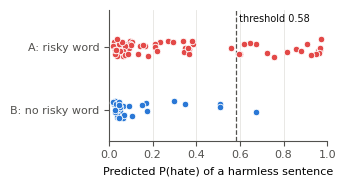

Registered F10 -> figures/fig_10_keyword_bias.png


In [21]:
plt.rcParams.update({'font.size': 8, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
                     'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white'})
rng = np.random.default_rng(SEED)
fig, ax = plt.subplots(figsize=(3.5, 1.9))
for y, (g, color) in enumerate([('B', '#2a78d6'), ('A', '#e34948')]):
    d = probe[probe['group'] == g]
    ax.scatter(d['p_hate'], y + rng.uniform(-0.15, 0.15, len(d)), s=22, color=color,
               edgecolor='white', linewidth=0.6, zorder=3)
ax.axvline(BIN_THR, color='#52514e', linestyle='--', linewidth=0.9)
ax.text(BIN_THR, 1.45, f' threshold {BIN_THR:.2f}', fontsize=7, color='#0b0b0b', va='center')
ax.set_yticks([0, 1], ['B: no risky word', 'A: risky word'])
ax.set_ylim(-0.5, 1.6)
ax.set_xlim(0, 1)
ax.set_xlabel('Predicted P(hate) of a harmless sentence')
ax.grid(axis='x', color='#e5e4e0', linewidth=0.6)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_10_keyword_bias.png'))
plt.show()
register_asset('F10', 'figures/fig_10_keyword_bias.png',
               'P(hate) of each harmless probe sentence, with vs without a risky word, and the decision threshold',
               NOTEBOOK_NAME, 'V. Results (keyword bias)',
               'Fig. X. Predicted hate probability for harmless sentences with (A) and without (B) insult-associated words. Points right of the dashed threshold are false positives.')

## Save all numbers (M12)

In [22]:
out = {
    'step': 'keyword_bias', 'notebook': NOTEBOOK_NAME, 'date': datetime.now().isoformat(timespec='seconds'),
    'seed': SEED, 'threshold': BIN_THR, 'train_hate_rate_pct': base_rate,
    'sentences': 'everyday harmless Banglish sentences, checked by the team as natural and non-hateful',
    'summary': summary.to_dict(orient='records'),
    'word_stats': word_stats.to_dict(orient='records'),
    'sentences': probe.to_dict(orient='records'),
}
path = os.path.join(REP_DIR, 'metrics_bias.json')
with open(path, 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2, ensure_ascii=False, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
print('Saved:', path)
register_asset('M12', 'evaluation_reports/metrics_bias.json',
               'All keyword bias test numbers: per-sentence predictions, group summary, word statistics',
               NOTEBOOK_NAME, 'V. Results / VII. Limitations',
               'Not a figure; source for every keyword bias number quoted in the text.')

Saved: /content/drive/MyDrive/ML_Project/results/evaluation_reports/metrics_bias.json
Registered M12 -> evaluation_reports/metrics_bias.json


## Summary

We tested the model on everyday harmless sentences, with and without words that are common in insults. The results are in T21 to T23 and F10. This is a small test (100 sentences), so it shows a pattern, not an exact rate.

## Remember this

- What we did: tested the model on everyday harmless sentences, with and without words that often appear in insults.
- Why: the demo showed a harmless sentence flagged as hate, and we wanted to know if it is a pattern, and whether the explanations can show the cause.
- Key number: 26.1% of harmless sentences with a risky word were flagged as hate (18 of 69), against 3.2% without one (1 of 31); SHAP named the risky word as the main reason in 55.1% of cases.